# One-dimensional (1D) Fourier transformation

In this notebook, we transform time-domain NMR data into a 1D spectrum using
SpectroChemPy processing tools.

In [1]:
import spectrochempy as scp

## FFT of 1D NMR spectra

First we open read some time domain data. Here is a NMD free induction decay (FID):

Requires the official ``spectrochempy-nmr`` plugin.
Install with: ``python -m pip install "spectrochempy[nmr]"``.

In [2]:
path = scp.preferences.datadir / "nmrdata" / "bruker" / "tests" / "nmr" / "topspin_1d"
fid = scp.nmr.read(path)
fid

NDDataset: [complex128] count (size: 12466)

The type of the data is complex:

In [3]:
fid.dtype

dtype('complex128')

We can represent both real and imaginary parts on the same plot using the `show_complex` parameter.

td =  12466


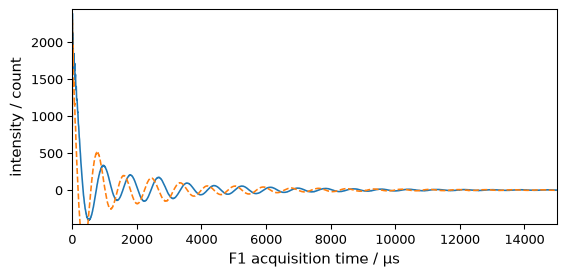

In [4]:
prefs = scp.preferences
prefs.figure.figsize = (6, 3)
_ = fid.plot(show_complex=True, xlim=(0, 15000))
print("td = ", fid.size)

Now we perform a Fast Fourier Transform (FFT):

si =  12466


NDDataset: [complex128] count (size: 12466)

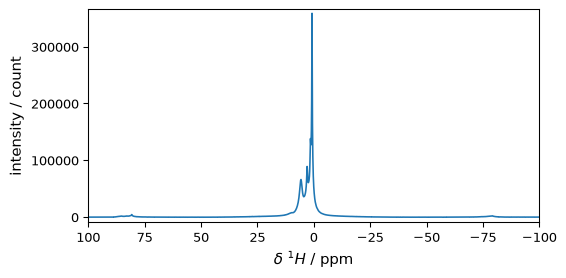

In [5]:
spec = scp.fft(fid)
_ = spec.plot(xlim=(100, -100))
print("si = ", spec.size)
spec

**Alternative notation**

si =  32768


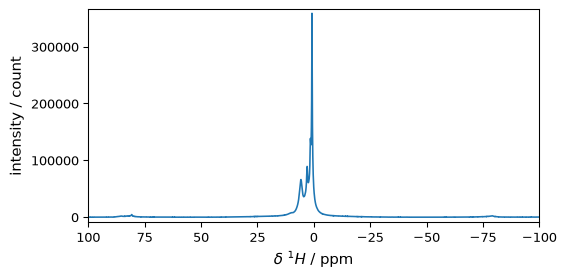

In [6]:
k = 1024
spec = fid.fft(size=32 * k)
_ = spec.plot(xlim=(100, -100))
print("si = ", spec.size)

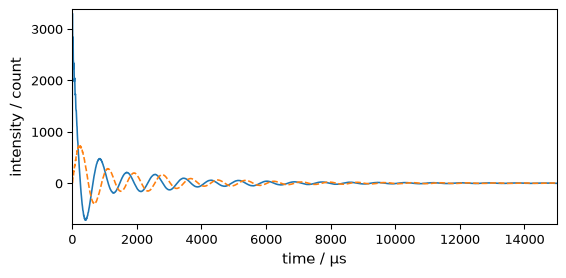

In [7]:
newfid = spec.ifft()
# x coordinate is in second (base units) so lets transform it
_ = newfid.plot(show_complex=True, xlim=(0, 15000))

Let's compare fid and newfid. There differs as a rephasing has been automatically applied after the first FFT (with
the parameters found in the original fid metadata: PHC0 and PHC1).

First point in the time domain of the real part is at the maximum.

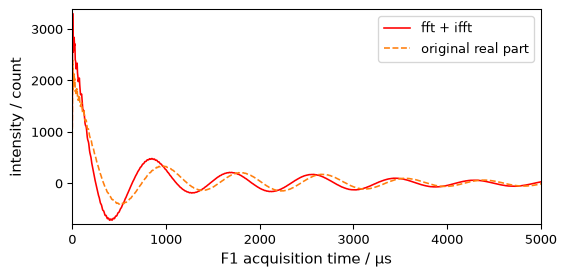

In [8]:
_ = newfid.real.plot(c="r", label="fft + ifft")
ax = fid.real.plot(clear=False, xlim=(0, 5000), ls="--", label="original real part")
_ = ax.legend()

First point in the time domain of the imaginary part is at the minimum.

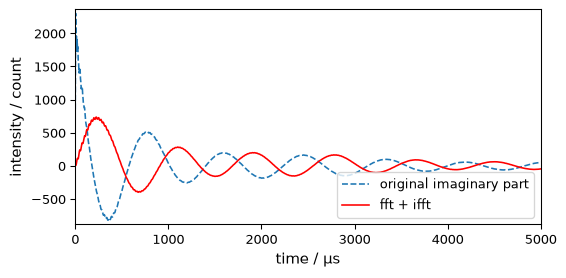

In [9]:
_ = fid.imag.plot(ls="--", label="original imaginary part")
ax = newfid.imag.plot(clear=False, xlim=(0, 5000), c="r", label="fft + ifft")
_ = ax.legend(loc="lower right")

## Preprocessing

### Line broadening
Often before applying FFT, some exponential multiplication `em`or other broadening filters such as `gm` or `sp`
are applied.
See the dedicated [apodization tutorial](apodization.rst).

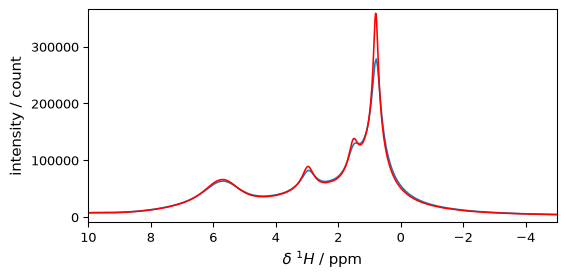

In [10]:
fid2 = fid.em(lb="50. Hz")
spec2 = fid2.fft()
_ = spec2.plot()
_ = spec.plot(
    clear=False, xlim=(10, -5), c="r"
)  # superpose the non broadened spectrum in red and show expansion.

### Zero-filling

In [11]:
print("td = ", fid.size)

td =  12466


In [12]:
td = 64 * 1024  # size: 64 K
fid3 = fid.zf_size(size=td)
print("new td = ", fid3.x.size)

new td =  65536


si =  65536


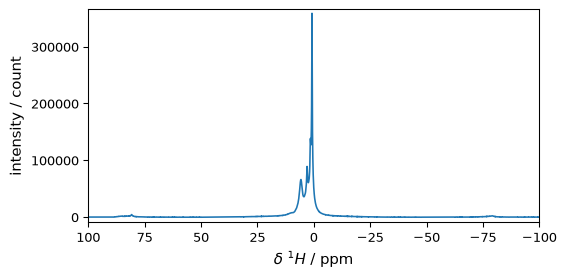

In [13]:
spec3 = fid3.fft()
_ = spec3.plot(xlim=(100, -100))
print("si = ", spec3.size)

### Time domain baseline correction
See the dedicated [Time domain baseline correction tutorial](td_baseline.rst).

### Magnitude calculation

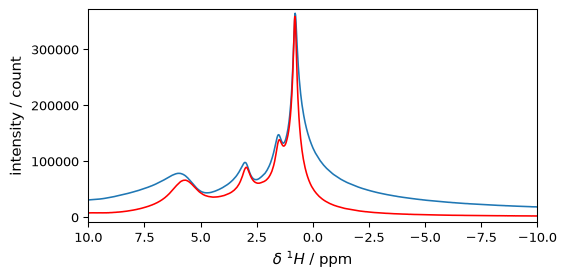

In [14]:
ms = spec.mc()
_ = ms.plot(xlim=(10, -10))
_ = spec.plot(clear=False, xlim=(10, -10), c="r")

### Power spectrum

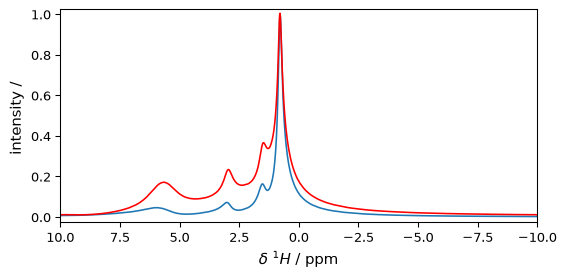

In [15]:
mp = spec.ps()
_ = (mp / mp.max()).plot()
_ = (spec / spec.max()).plot(
    clear=False, xlim=(10, -10), c="r"
)  # Here we have normalized the spectra at their max value.

# Real Fourier transform

In some case, it might be interesting to perform real Fourier transform . For instance, as a demonstration,
we will independently transform real and imaginary part of the previous fid, and recombine them to obtain the same
result as when performing complex fourier transform on the complex dataset.

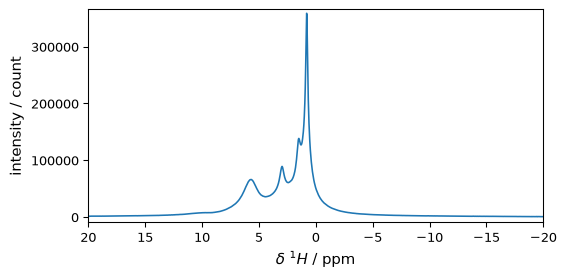

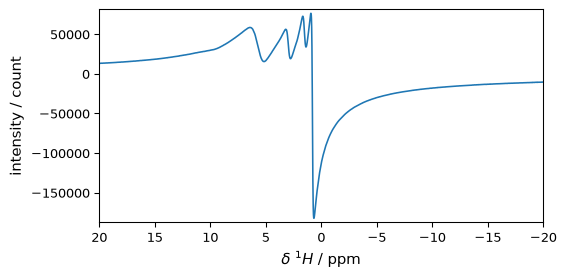

In [16]:
lim = (-20, 20)
_ = spec3.plot(xlim=lim)
_ = spec3.imag.plot(xlim=lim)

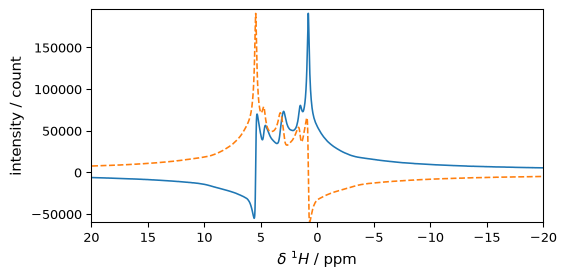

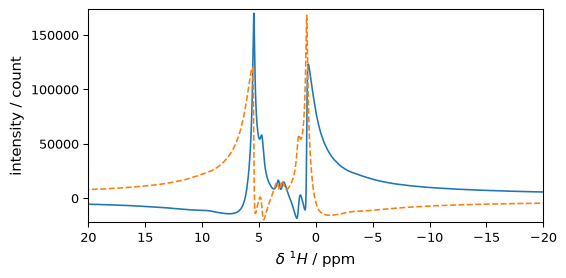

In [17]:
Re = fid3.real.astype("complex64")
fR = Re.fft()
_ = fR.plot(xlim=lim, show_complex=True)
Im = fid3.imag.astype("complex64")
fI = Im.fft()
_ = fI.plot(xlim=lim, show_complex=True)

Recombination:

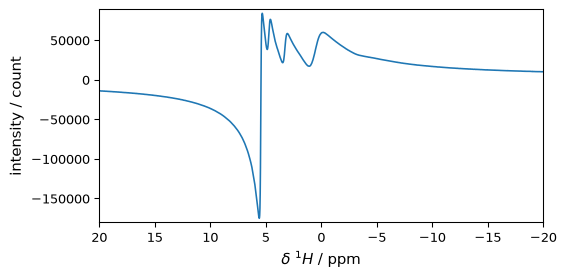

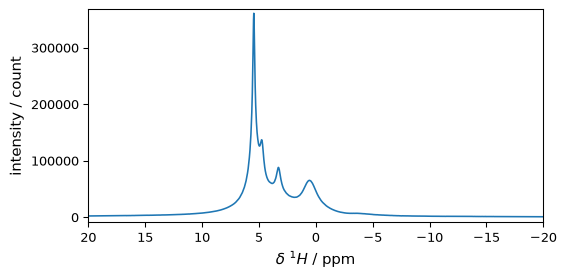

In [18]:
_ = (fR - fI.imag).plot(xlim=lim)
_ = (fR.imag + fI).plot(xlim=lim)